### PREPROCESSING DATA
read the uploaded data set
use panda to read data set 

#### Perform EDA 
exploratory data analysis

regression : see target labelc column if it is in continous numeric values 

classification: see target label column in form of classes yes no cloudy warm etc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek

In [2]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

In [3]:
df.shape #rows columns

(274, 14)

In [4]:
df.info() #data types of each row 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      273 non-null    float64
 1   Gender                   273 non-null    float64
 2   Chest pain type          272 non-null    float64
 3   BP                       273 non-null    float64
 4   Cholesterol              273 non-null    float64
 5   FBS over 120             273 non-null    float64
 6   EKG results              273 non-null    float64
 7   Max HR                   273 non-null    float64
 8   Exercise angina          273 non-null    float64
 9   ST depression            273 non-null    float64
 10  Slope of ST              273 non-null    float64
 11  Number of vessels fluro  273 non-null    float64
 12  Thallium                 273 non-null    float64
 13  Heart Disease            273 non-null    object 
dtypes: float64(13), object(1)


In [5]:
df.columns #only columns

Index(['Age', 'Gender', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease'],
      dtype='object')

In [6]:
df.dtypes #only datatypes

Age                        float64
Gender                     float64
Chest pain type            float64
BP                         float64
Cholesterol                float64
FBS over 120               float64
EKG results                float64
Max HR                     float64
Exercise angina            float64
ST depression              float64
Slope of ST                float64
Number of vessels fluro    float64
Thallium                   float64
Heart Disease               object
dtype: object

In [7]:

df.describe() #calculates statistical info count min max, mean mode median

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,273.000000,273.000000,272.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,54.454212,0.681319,3.165441,131.366300,249.967033,0.146520,1.025641,149.648352,0.329670,1.050549,1.586081,0.673993,4.692308
std,9.115210,0.466821,0.951897,17.874087,51.495171,0.354276,0.997829,23.227317,0.470957,1.141887,0.613054,0.950977,1.940431
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,154.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,282.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [8]:
df.head() #first five

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,Presence
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,Absence
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,Presence
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,Absence
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,Absence


In [9]:
df.tail() #last five

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
269,44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,Absence
270,56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,Absence
271,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,Absence
272,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,Presence
273,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,Presence


In [10]:
df.nunique()

Age                         41
Gender                       2
Chest pain type              4
BP                          47
Cholesterol                144
FBS over 120                 2
EKG results                  3
Max HR                      90
Exercise angina              2
ST depression               39
Slope of ST                  3
Number of vessels fluro      4
Thallium                     3
Heart Disease                2
dtype: int64

In [11]:
print(df.duplicated())
print(df.duplicated().sum()) #find duplicated rows it learns (ratta) if there are duplicates if a single column is duplicate then that entry is not considerede duplicate

0      False
1      False
2      False
3      False
4      False
       ...  
269     True
270    False
271    False
272    False
273     True
Length: 274, dtype: bool
3


In [12]:
#df.drop_duplicates(inplace=True) no change in original dataset
df=df.drop_duplicates()

In [13]:
df.isnull().sum() #removes null 
#tells no of null entries in each row


Age                        1
Gender                     1
Chest pain type            2
BP                         1
Cholesterol                1
FBS over 120               1
EKG results                1
Max HR                     1
Exercise angina            1
ST depression              1
Slope of ST                1
Number of vessels fluro    1
Thallium                   1
Heart Disease              1
dtype: int64

In [14]:
# remove that row
df.dropna(how='any',inplace=True) #if any one col is empty will drop the row eg row 226
df.dropna(how='all',inplace=True) #if all col are empty will drop the row eg row 227

In [15]:

# or fill that empty columnb with any value 
# mean med mode any if data is numeric
# object type data fill it with mode
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median()) #mean median or mode any

In [16]:
#objects to numeric conversion
#ML ONLY WORKS FOR NUMERICS
# use for catagorical strings ( absence presence )

categorical_cols= df.select_dtypes(include="object").columns
for col in categorical_cols:
    df[col]=LabelEncoder().fit_transform(df[col])
df.tail()

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
267,52.0,1.0,3.0,172.0,199.0,1.0,0.0,162.0,0.0,0.5,1.0,0.0,7.0,0
268,44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,0
270,56.0,0.0,2.0,140.0,294.0,0.0,2.0,153.0,0.0,1.3,2.0,0.0,3.0,0
271,57.0,1.0,4.0,140.0,192.0,0.0,0.0,148.0,0.0,0.4,2.0,0.0,6.0,0
272,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1


Normalization / standaidize min max normalization -> means the whole column is converted in to 0,1. it is either scaled up pr scaled down Z-LINE standarziation=1, mean=0. the std is converted to 1 and mean value is given 0. this is also scaled up and down model can give more importance to one more like the one with value more will be given more importance and 0, 1 would be given less importance RULES: -> on which columns we are applying normalization and standarizatopn
1. 
Target column never standarize and normailz
2. d
categorical column are also never standized and normailzed -> gender, chestpain,
3.  BS
Applied on age because continuous value-> BP,


In [17]:
columns_to_scale = ['Age','BP','Cholesterol','Max HR','ST depression']
#scaler = MinMaxScaler()
scalar = StandardScaler()
df[columns_to_scale]=scalar.fit_transform(df[columns_to_scale])

In [18]:
df.head()
df.describe()
#standarization -> unifom distirbution converted std=1 mean =0 values scaled according to this one and 0 th values is set. the mean is showing e^-value
#means 0 and std us 1 in columns we applied standarization
#in columns we apply normalization 0,1 is set but here the data set itself according to the graph and scale it self so that std =1 and mean =0

,Age,Gender,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,2.690000e+02,269.000000,269.000000,2.690000e+02,2.690000e+02,269.000000,269.000000,2.690000e+02,269.000000,2.690000e+02,269.000000,269.000000,269.000000,269.000000
mean,-9.575158e-17,0.680297,3.171004,2.748731e-16,6.933735e-17,0.148699,1.026022,4.622490e-16,0.330855,-1.254676e-16,1.587361,0.672862,4.702602,0.446097
std,1.001864e+00,0.467231,0.950518,1.001864e+00,1.001864e+00,0.356455,0.997792,1.001864e+00,0.471398,1.001864e+00,0.614492,0.944765,1.941503,0.498012
min,-2.824104e+00,0.000000,1.000000,-2.089922e+00,-2.404767e+00,0.000000,0.000000,-3.403499e+00,0.000000,-9.158860e-01,1.000000,0.000000,3.000000,0.000000
25%,-7.203297e-01,0.000000,3.000000,-6.339091e-01,-7.162860e-01,0.000000,0.000000,-7.173569e-01,0.000000,-9.158860e-01,1.000000,0.000000,3.000000,0.000000
50%,5.474506e-02,1.000000,3.000000,-7.390402e-02,-9.523544e-02,0.000000,2.000000,1.491407e-01,0.000000,-2.172023e-01,2.000000,0.000000,3.000000,0.000000
75%,7.190948e-01,1.000000,4.000000,4.861011e-01,6.034464e-01,0.000000,2.000000,7.123641e-01,1.000000,4.814814e-01,2.000000,1.000000,7.000000,1.000000
max,2.490694e+00,1.000000,4.000000,3.846132e+00,6.095862e+00,1.000000,2.000000,2.272060e+00,1.000000,4.498913e+00,3.000000,3.000000,7.000000,1.000000


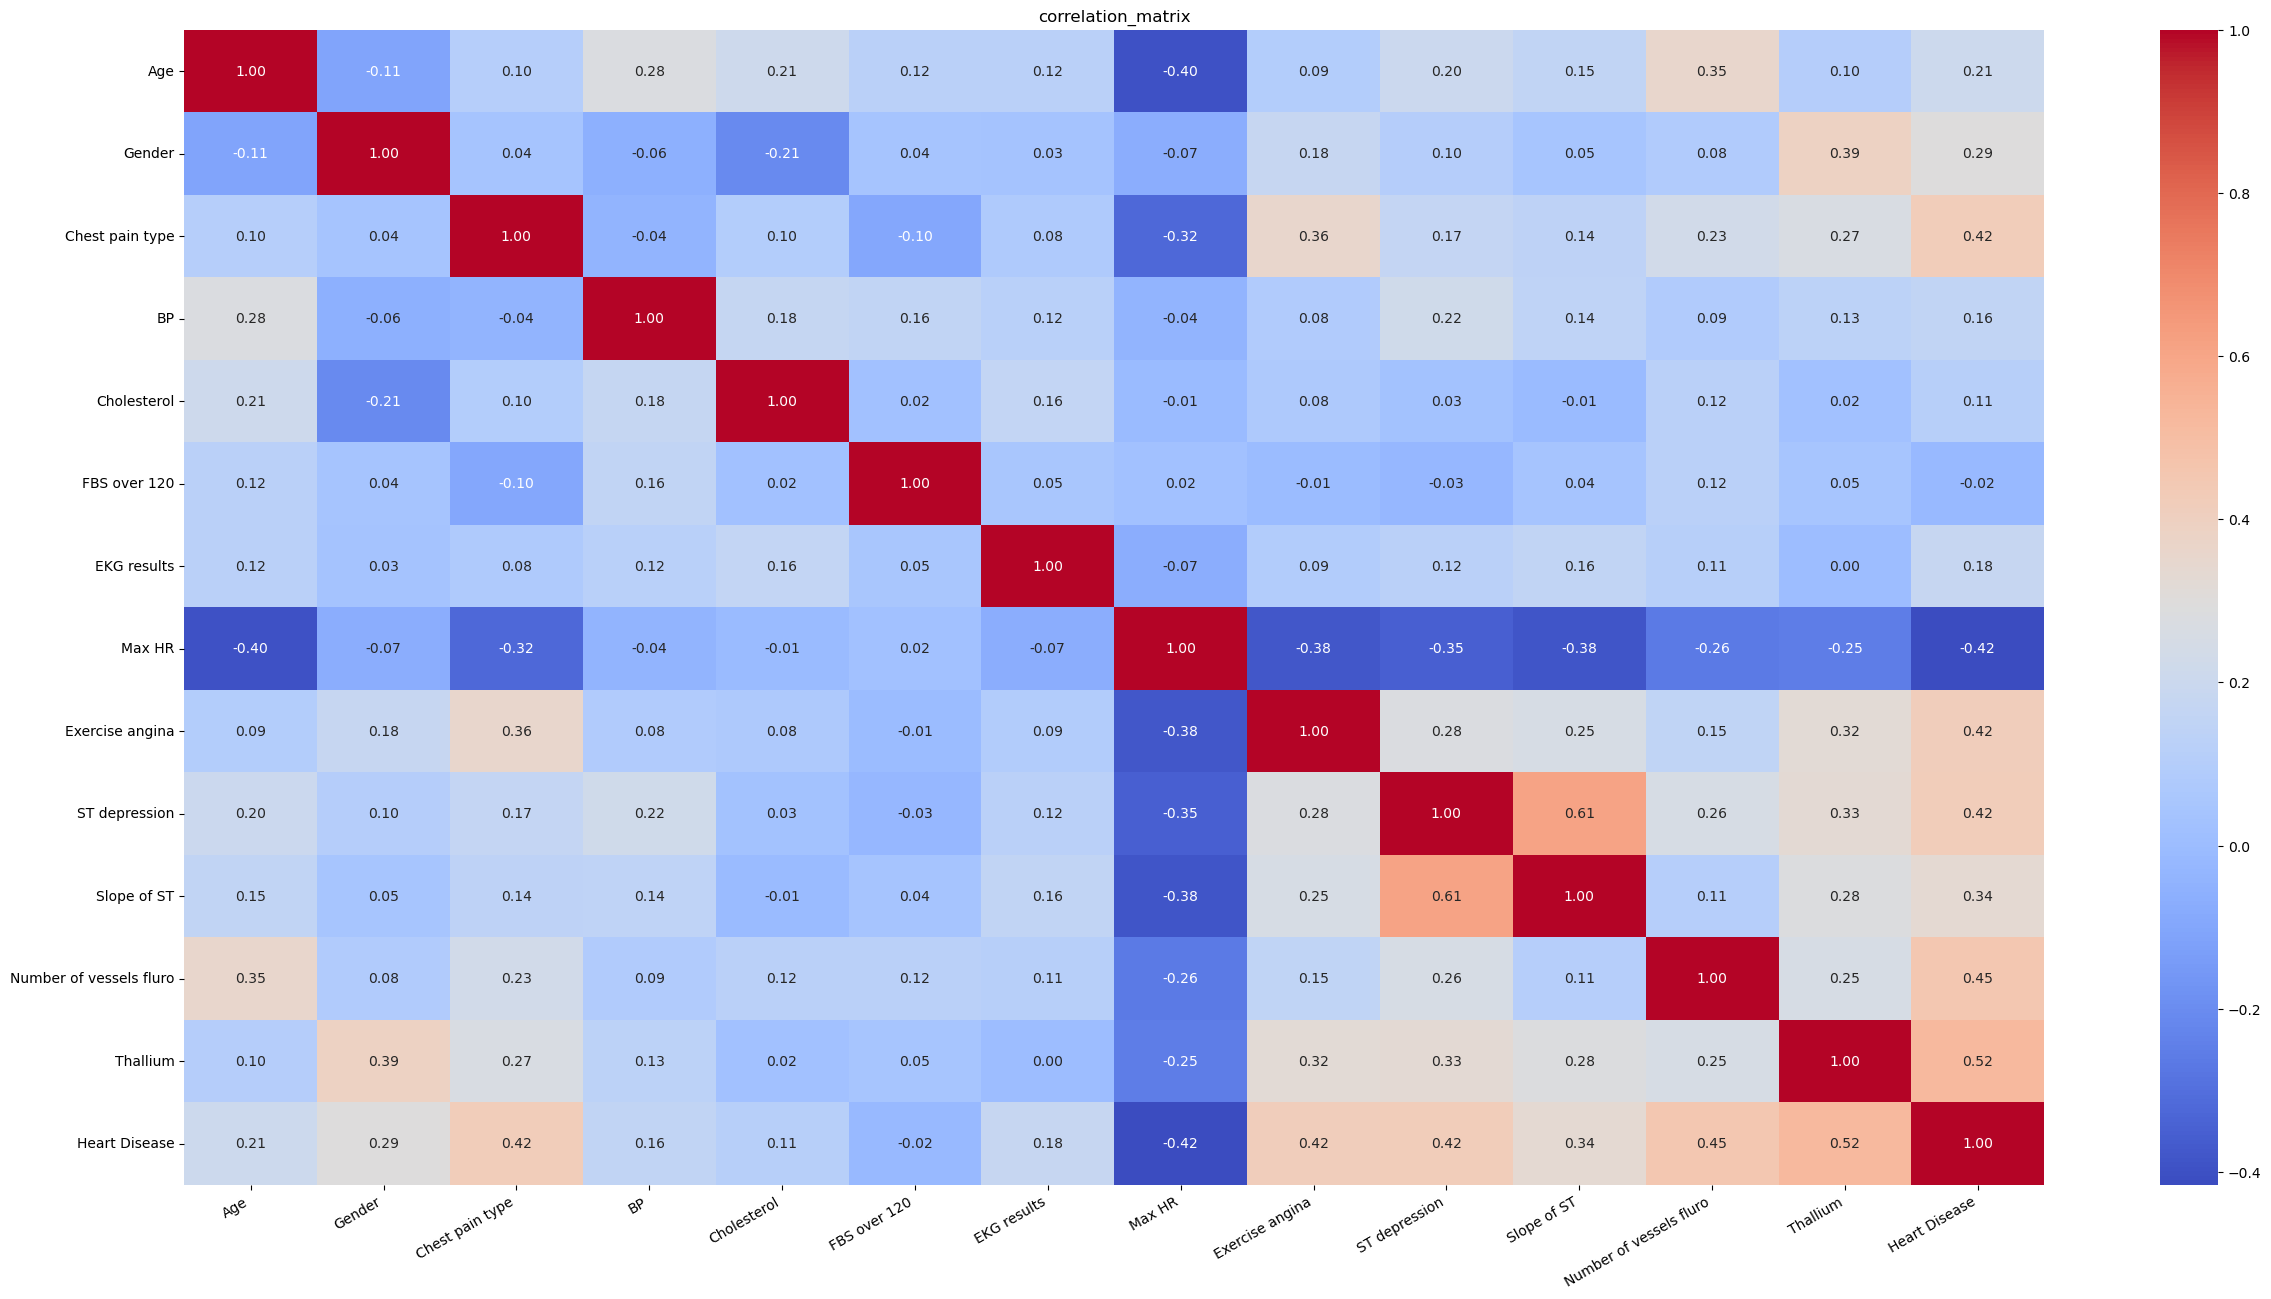

In [19]:
correlation_matrix =df.corr() #built in function for this matrix
plt.figure(figsize=(30,15)) #plt and sns both libraries used for graph generation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm' ,fmt='.2f') # annot='False' numbers would not be shown  cmap-> for colur scheme 
#fmt for floating number
plt.title('correlation_matrix')
plt.xticks(rotation=30,ha='right') #x axis label is rotated to 30 degree
plt.show() #graph shown
#values in the graph through heatmap.
#more near to 0 more unimportant, can see what is more important for heartdisease by looking at these values

1. matrix relation would be +1 if increase in one is causng increase in another value
2.  0 means randomly increasing and dcreasing
3.  -1 means increase in is causing decrease in the other column|

In [20]:
#dropping unnesscary columns
df.drop(columns=['Age'],inplace=True)

In [21]:
#is above drop command run again it would cause error. because already dropped. 

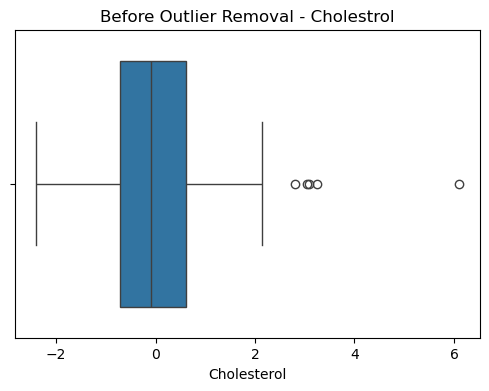

In [22]:
#removing outlier 
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cholesterol'])
plt.title('Before Outlier Removal - Cholestrol')
plt.show()
#Means 25% 25% 25% 25% values divied and outside these the circles are outlier 

In [23]:
#inter quratile range
Q1=df['Cholesterol'].quantile(0.25)
Q3=df['Cholesterol'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Cholesterol']>=lower_bound) & (df['Cholesterol'] <=upper_bound)]

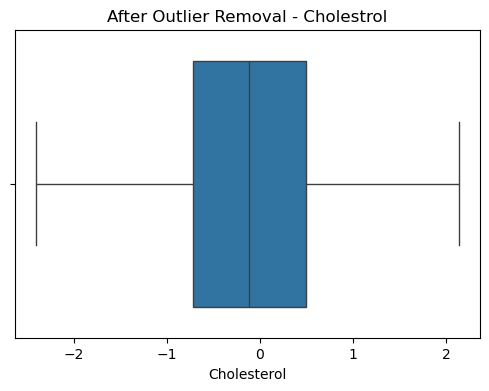

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Cholesterol'])
plt.title('After Outlier Removal - Cholestrol')
plt.show()

Handle class Imbalance we would appoint it at target column data imablance because 147 more and it would show baisness and accuracy of 99% which would be wrong. and a the time of testing the data would be different and hence accuracy would be 50%. Hence we need to handle this imbalance
1. 
suppose 9000 yes -> oversampli
2. g
100 -> No undersampl
3. ng
combination these are three ways to handle class imbl



ance
Oversampling: would increase the 100 values to 8000 values. would synthetictally itself generate new data have further types but we would do SMOTE

Undersampling: Would decrease the majority class from 9000 to 1000 and its technique name is Tonecklinks

Combination: Decrease the 9000 and increase the 100 one 5000 and 5000 technique is SmoteToneck

In [25]:
print(df['Heart Disease'].value_counts())

Heart Disease
0    146
1    118
Name: count, dtype: int64


In [26]:
X=df.drop(columns=['Heart Disease']) #column dropped and all columns returned except these 
y=df['Heart Disease']
#X= input (A-M) input features denoted by captial letters y= output -> target output denoted by small letter

In [27]:
print(f'Orginal Dataset Size: {y.value_counts()}')
#balance= SMOTE(random_state=42)
#balance -Tomeklinks()
balance=SMOTETomek(random_state=42)
X_resampled,y_resampled= balance.fit_resample(X,y)
print(f'Resampled Dataset Size: {y_resampled.value_counts()}')
#minority one increase and majoirty oneds decreased

Orginal Dataset Size: Heart Disease
0    146
1    118
Name: count, dtype: int64
Resampled Dataset Size: Heart Disease
1    134
0    134
Name: count, dtype: int64


In [28]:
#when data set is small we would want new values to come we would do oversample and when dataset large undersample and 
#when in between combination

In [29]:
df=pd.concat([X,y], axis=1) #x inpur and y single output we concate them to make new file. axis =1 mean column by column add
df.to_csv('Updated.csv',index=False) #convert to csv. index= False means index should not print index=true and in this new column is formed and we dont 
#want that